<div style="width: 100%; height: 5px; background-color: green;"></div>
Here we load wav files from a Hugging Face dataset.
Then we prepare them to be encoded by Encodec at some "bandwidth" (determining a specific number of quantized tokens).
We then encode to tokens, decode back to audio and compare the reconstructed audio with the original.
<div style="width: 100%; height: 5px; background-color: green;"></div>

In [1]:
from datasets import load_dataset, load_from_disk, Audio
from transformers import EncodecModel, AutoProcessor

In [2]:
import librosa
import torch
import os
import numpy as np

In [3]:
import matplotlib.pyplot as plt
from IPython.display import Audio, display

<div style="width: 100%; height: 20px; background-color: green;"></div>
<b>Parameters</b>

In [4]:
dspath='/slowdisk/esteban/scratchdata/syntex24/data7wav/syn7wav24_HFdataset'
Kbs = 3  # Supported bandwidths are 1.5kbps (n_q = 2), 3 kbps (n_q = 4), 6 kbps (n_q = 8) and 12 kbps (n_q =16) and 24kbps (n_q=32).
dataSampleNumber=43 

In [5]:
# load the model + processor (for pre-processing the audio)
model = EncodecModel.from_pretrained("facebook/encodec_24khz")
model.config.target_bandwidths = [Kbs] # Supported bandwidths are 1.5kbps (n_q = 2), 3 kbps (n_q = 4), 6 kbps (n_q = 8) and 12 kbps (n_q =16) and 24kbps (n_q=32).
processor = AutoProcessor.from_pretrained("facebook/encodec_24khz", use_fast=False)

In [6]:
# This is for manual loading of audio "as needed"  
def load_audio_for_encodec(sample, dataset_root, target_sr=24000):
    """Load audio in the format encodec expects"""
    relative_audio_path = sample['audio']  # e.g., "train/filename.wav"
    full_audio_path = os.path.join(dataset_root, relative_audio_path)
    
    audio_array, sr = librosa.load(full_audio_path, sr=target_sr, mono=True)
    
    # Convert to torch tensor and add batch dimension if needed
    audio_tensor = torch.tensor(audio_array).float()
    # if audio_tensor.dim() == 1:
    #     audio_tensor = audio_tensor.unsqueeze(0)  # Add channel dimension
    
    return audio_tensor

In [7]:
#ds = load_dataset("/slowdisk/esteban/scratchdata/syntex24/data7wav/syn7wav24_HFdataset")
ds = load_from_disk(dspath)['val']

In [8]:
sample=ds[dataSampleNumber]
audio_sample = load_audio_for_encodec(sample, dspath, processor.sampling_rate)

In [9]:
audio_sample.shape

torch.Size([120000])

In [10]:
# pre-process the inputs
inputs = processor(raw_audio=audio_sample, sampling_rate=processor.sampling_rate, return_tensors="pt")
inputs["input_values"].shape

torch.Size([1, 1, 120000])

In [11]:
# explicitly encode then decode the audio inputs
encoder_outputs = model.encode(inputs["input_values"], inputs["padding_mask"])

audio_recon = model.decode(encoder_outputs.audio_codes, encoder_outputs.audio_scales, inputs["padding_mask"])[0]

encoder_outputs.audio_codes.shape

torch.Size([1, 1, 4, 375])

In [12]:
# you can also extract the discrete codebook representation for LM tasks
# output: concatenated tensor of all the representations
audio_codes = model(inputs["input_values"], inputs["padding_mask"]).audio_codes
audio_codes.shape

torch.Size([1, 1, 4, 375])

In [13]:
quantized_latents = model.quantizer.decode(audio_codes.squeeze(0)) # I think we are squeezing out the channel dimension  which is always 1 for the 24kHz model
quantized_latents.shape

torch.Size([4, 128, 375])

<div style="width: 100%; height: 20px; background-color: green;"></div>
<b>COMPARE original and reconstructed</b>

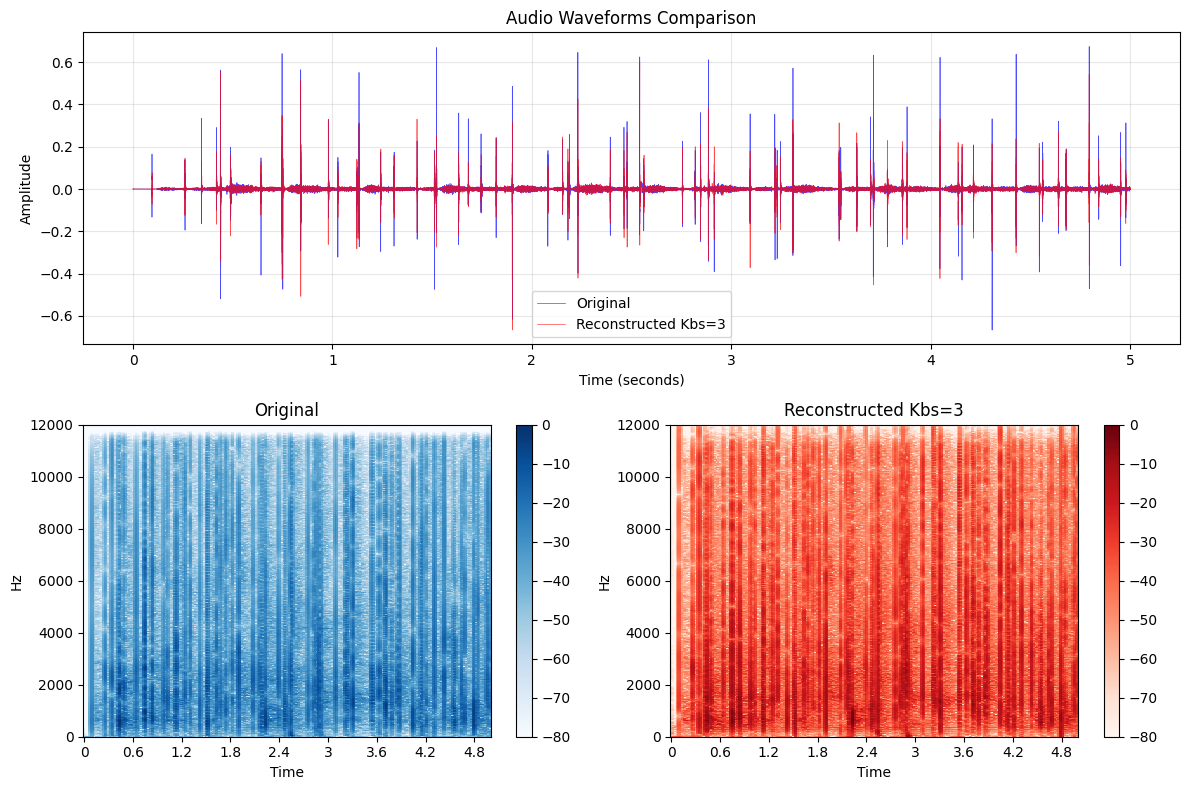


AUDIO PLAYBACK CONTROLS
Original


Reconstructed Kbs=3


In [14]:
#COMPARE original and reconstructed

audio1 = audio_sample.numpy()
audio2 = audio_recon.detach().flatten().numpy()

# Create time axes for plotting
time1 = np.linspace(0, len(audio1) / processor.sampling_rate, len(audio1))
time2 = np.linspace(0, len(audio2) / processor.sampling_rate, len(audio2))

# Plot both audio files
plt.figure(figsize=(12, 8))

# Plot waveforms
plt.subplot(2, 1, 1)
plt.plot(time1, audio1, color='blue', alpha=0.7, linewidth=0.5, label=f'Original')
plt.plot(time2, audio2, color='red', alpha=0.7, linewidth=0.5, label=f'Reconstructed Kbs={Kbs}')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.title('Audio Waveforms Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot spectrograms side by side
plt.subplot(2, 2, 3)
D1 = librosa.amplitude_to_db(np.abs(librosa.stft(audio1)), ref=np.max)
librosa.display.specshow(D1, sr=processor.sampling_rate, x_axis='time', y_axis='hz', cmap='Blues')
plt.title(f'Original')
plt.colorbar()

plt.subplot(2, 2, 4)
D2 = librosa.amplitude_to_db(np.abs(librosa.stft(audio2)), ref=np.max)
librosa.display.specshow(D2, sr=processor.sampling_rate, x_axis='time', y_axis='hz', cmap='Reds')
plt.title(f'Reconstructed Kbs={Kbs}')
plt.colorbar()

plt.tight_layout()
plt.show()

# Audio playback controls
print("\n" + "="*50)
print("AUDIO PLAYBACK CONTROLS")
print("="*50)

print(f'Original')
display(Audio(audio1, rate=processor.sampling_rate))
print(f'Reconstructed Kbs={Kbs}')
display(Audio(audio2, rate=processor.sampling_rate))